In [1]:
# Import Libraries

import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Complaint Dataset

complaints = [
    "Internet not working",
    "No internet since morning",
    "Internet connection is down",
    
    "Wrong bill charged",
    "Incorrect billing amount",
    "Charged extra in invoice",
    
    "App keeps crashing",
    "Application crashes frequently",
    "Unable to use the mobile app"
]

df = pd.DataFrame({
    "Complaint": complaints
})

display(df)

,Complaint
0,Internet not working
1,No internet since morning
2,Internet connection is down
3,Wrong bill charged
4,Incorrect billing amount
5,Charged extra in invoice
6,App keeps crashing
7,Application crashes frequently
8,Unable to use the mobile app


In [3]:
# Text Preprocessing

def preprocess(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

df["Cleaned"] = df["Complaint"].apply(preprocess)

In [4]:
# TF-IDF Vectorization

vectorizer = TfidfVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(df["Cleaned"])

In [5]:
# Cosine Similarity Matrix

similarity_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=df["Complaint"],
    columns=df["Complaint"]
)

display(sim_df)

Complaint,Internet not working,No internet since morning,Internet connection is down,Wrong bill charged,Incorrect billing amount,Charged extra in invoice,App keeps crashing,Application crashes frequently,Unable to use the mobile app
Complaint,,,,,,,,,
Internet not working,1.000000,0.350353,0.350353,0.000000,0.0,0.000000,0.000000,0.0,0.000000
No internet since morning,0.350353,1.000000,0.350353,0.000000,0.0,0.000000,0.000000,0.0,0.000000
Internet connection is down,0.350353,0.350353,1.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
Wrong bill charged,0.000000,0.000000,0.000000,1.000000,0.0,0.330855,0.000000,0.0,0.000000
Incorrect billing amount,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.0,0.000000
Charged extra in invoice,0.000000,0.000000,0.000000,0.330855,0.0,1.000000,0.000000,0.0,0.000000
App keeps crashing,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.0,0.224739
Application crashes frequently,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.0,0.000000
Unable to use the mobile app,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.224739,0.0,1.000000


In [6]:
# Group Similar Complaints

threshold = 0.30

group_ids = [-1] * len(df)

current_group = 1

for i in range(len(df)):
    
    if group_ids[i] == -1:
        group_ids[i] = current_group
        
        for j in range(i+1, len(df)):
            if similarity_matrix[i][j] >= threshold:
                group_ids[j] = current_group
        
        current_group += 1

df["Group ID"] = group_ids

display(df[["Complaint", "Group ID"]])

,Complaint,Group ID
0,Internet not working,1
1,No internet since morning,1
2,Internet connection is down,1
3,Wrong bill charged,2
4,Incorrect billing amount,3
5,Charged extra in invoice,2
6,App keeps crashing,4
7,Application crashes frequently,5
8,Unable to use the mobile app,6


In [7]:
# Complaint Count Per Group

group_counts = df["Group ID"].value_counts().sort_index()

display(group_counts)

Group ID
1    3
2    2
3    1
4    1
5    1
6    1
Name: count, dtype: int64

In [8]:
# Extract Top Keywords Per Group

feature_names = vectorizer.get_feature_names_out()

for group in sorted(df["Group ID"].unique()):
    
    group_texts = df[df["Group ID"] == group]["Cleaned"]
    
    group_vectors = vectorizer.transform(group_texts)
    
    word_scores = group_vectors.sum(axis=0).A1
    
    top_indices = word_scores.argsort()[-3:][::-1]
    
    keywords = [feature_names[i] for i in top_indices]
    
    print(f"Group {group} Keywords:", keywords)

Group 1 Keywords: ['internet', 'morning', 'working']
Group 2 Keywords: ['charged', 'wrong', 'invoice']
Group 3 Keywords: ['incorrect', 'billing', 'wrong']
Group 4 Keywords: ['keeps', 'crashing', 'app']
Group 5 Keywords: ['application', 'crashes', 'frequently']
Group 6 Keywords: ['use', 'mobile', 'unable']


In [9]:
# Generate Summary Labels

group_summaries = {}

for group in sorted(df["Group ID"].unique()):
    
    group_texts = df[df["Group ID"] == group]["Cleaned"]
    
    group_vectors = vectorizer.transform(group_texts)
    
    word_scores = group_vectors.sum(axis=0).A1
    
    top_word = feature_names[word_scores.argmax()]
    
    group_summaries[group] = f"{top_word.title()} Related Issue"

print(group_summaries)

{np.int64(1): 'Internet Related Issue', np.int64(2): 'Charged Related Issue', np.int64(3): 'Billing Related Issue', np.int64(4): 'Crashing Related Issue', np.int64(5): 'Application Related Issue', np.int64(6): 'Mobile Related Issue'}


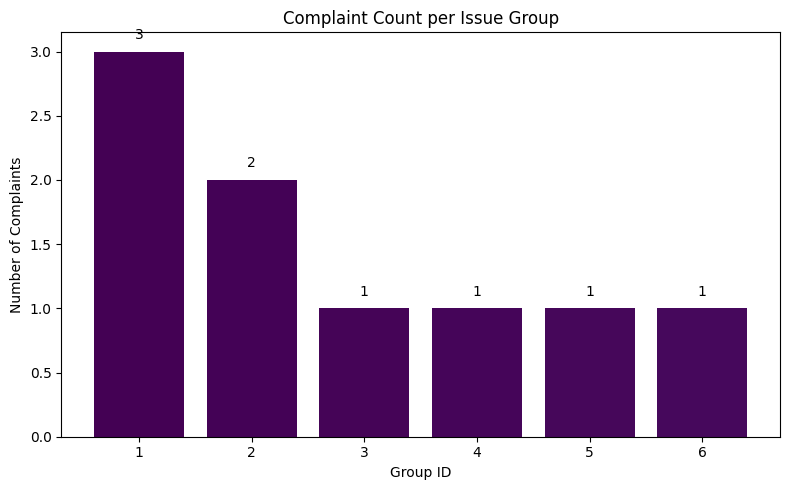

In [10]:
# Visualization: Complaint Count by Group

plt.figure(figsize=(8,5))

bars = plt.bar(
    group_counts.index.astype(str),
    group_counts.values,
    color=plt.cm.viridis(range(len(group_counts)))
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        str(height),
        ha='center'
    )

plt.title("Complaint Count per Issue Group")
plt.xlabel("Group ID")
plt.ylabel("Number of Complaints")

plt.tight_layout()
plt.show()

In [11]:
# Final CRM Report

print("===== CRM COMPLAINT SUMMARY REPORT =====")

print("Total Complaints:", len(df))
print("Number of Issue Groups:", df["Group ID"].nunique())

print("\nTop Issues:")
for group, summary in group_summaries.items():
    count = group_counts[group]
    print(f"Group {group}: {summary} ({count} complaints)")

===== CRM COMPLAINT SUMMARY REPORT =====
Total Complaints: 9
Number of Issue Groups: 6

Top Issues:
Group 1: Internet Related Issue (3 complaints)
Group 2: Charged Related Issue (2 complaints)
Group 3: Billing Related Issue (1 complaints)
Group 4: Crashing Related Issue (1 complaints)
Group 5: Application Related Issue (1 complaints)
Group 6: Mobile Related Issue (1 complaints)
